#### Imports

In [1]:
import numpy as np
import matplotlib.ticker as ticker
import pickle, sys, os, json, glob, tables, subprocess, shutil, random
from astropy.coordinates import SkyCoord
from astropy import units as u
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from pathlib import Path
from ctapipe.io import read_table, write_table
pd.set_option("display.max_columns", None)

from lstchain import __path__ as lstchain_path
from lstchain import __version__ as lstchain_version
version_lstchain = f"v{(lstchain_version).split('.dev')[0]}"

import utils

print(f"Using lstchain version {version_lstchain} from:\n{lstchain_path[0]}")

Using lstchain version v0.12.0 from:
/fefs/aswg/workspace/juan.jimenez/softs/conda/envs/env-lst-12/lib/python3.11/site-packages/lstchain


#### Fixed paths and parameters

In [2]:
root_dl1 = "/fefs/onsite/data/lst-pipe/LSTN-01/DL1/????????/v*/tailcut*/"
root_dl2 = "/fefs/onsite/data/lst-pipe/LSTN-01/DL2/????????/v*/tailcut*/nsb_tuning_*/"
root_data = "/fefs/aswg/workspace/juan.jimenez/data/"

default_config_lstchain_dl2 = os.path.join(lstchain_path[0], "data/lstchain_standard_config.json")
default_config_lstchain_dl3 = os.path.join("./data/config/general/irf_dl3_tool_config.json")

root_rfs = "/fefs/aswg/data/models/AllSky/20240918_v0.10.12_allsky_nsb_tuning_*/"
root_mcs = "/fefs/aswg/data/mc/DL2/AllSky/20240918_v0.10.12_allsky_nsb_tuning_*/TestingDataset/"
root_irf = "/fefs/aswg/data/mc/IRF/AllSky/20250212_v0.10.17_allsky_interp_dl2_irfs_nsb_*/TestingDataset/"

### Parameters:

In [3]:
file_srun_ly = "./data/selection/selected_runs.csv"

source_name = "Crab"
str_dec = "dec_2276"

nsruns_batch = 10
PROCESS_INLINE    = False
OVERWRITE         = True
USE_STANDARD_IRFS = False

ROOT = Path(os.getcwd())
ROOT_DATA  = ROOT / "data"
DCHECK_DIR = ROOT_DATA / "datachecks"
FNAME_DCHECK_FLAT_SRUNWISE = DCHECK_DIR / "datachecks_flat.parquet"
FNAME_DCHECK_FLAT_RUNWISE = DCHECK_DIR / "datachecks_flat_runwise.parquet"

excluded_runs = [23895, 21818, 22058, 22059, 22600, 22983, 22986, 23010, 23092]

### Reading config and DL1 information summary

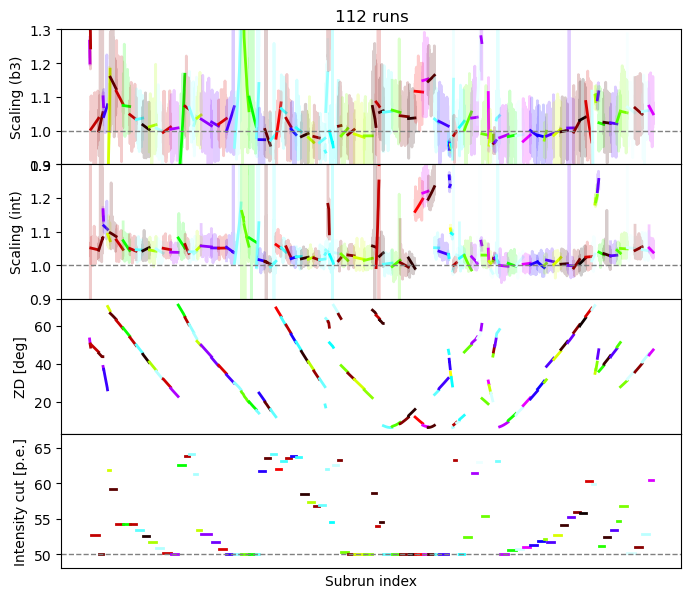

In [4]:
obs_ids = np.array(pd.read_csv(file_srun_ly)["obs_id"])
obs_ids = [item for item in obs_ids if item not in set(excluded_runs)]

df_run = pd.read_parquet(FNAME_DCHECK_FLAT_RUNWISE)
df_srun = pd.read_parquet(FNAME_DCHECK_FLAT_SRUNWISE)

df_srun["time"] = pd.to_datetime(df_srun["time"])
df_run = df_run[df_run["obs_id"].isin(obs_ids)].reset_index(drop=True)
df_srun = df_srun[df_srun["obs_id"].isin(obs_ids)].reset_index(drop=True)

# Use the robust, outlier-trimmed fit-based scaling ("ly_b3_scaling") that
# notebook 1 already computed per-subrun, rather than the raw noisy 1/ly_b3.
# Rows with no valid fit (NaN) are dropped here, so the "no scaling factor
# found" warning below correctly skips those subruns.
scaling_factors = {
    (int(row["obs_id"]), int(row["subrun"])): row["ly_b3_scaling"]
    for _, row in df_srun.iterrows()
    if pd.notna(row["ly_b3_scaling"])
}

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(8, 7), sharex=True)
rng = np.random.default_rng(seed=42)
for run, run_data in df_srun.groupby("obs_id"):
    filtered_data = run_data.iloc[1:-1]
    random_color = [*rng.random(3)[:1], random.choice([1, 0]), random.choice([1, 0])]
    
    ax1.plot(filtered_data.index, (1 / filtered_data["ly_b3"]), color=random_color, alpha=0.2, lw=2)
    ax1.plot(filtered_data.index, filtered_data["ly_b3_scaling"], color=random_color, lw=2)
    ax2.plot(filtered_data.index, (1 / filtered_data["ly_i"]), color=random_color, alpha=0.2, lw=2)
    ax2.plot(filtered_data.index, filtered_data["ly_i_scaling"], color=random_color, lw=2)
    ax3.plot(filtered_data.index, filtered_data["zd"], color=random_color, lw=2)
    ax4.plot(filtered_data.index, filtered_data["intensity_cut"], color=random_color, lw=2, label=f"Run {run}")

ax1.axhline(1, color="0.5", ls="--", lw=1)
ax2.axhline(1, color="0.5", ls="--", lw=1)
ax4.axhline(50, color="0.5", ls="--", lw=1)

ax1.set(ylabel="Scaling (b3)", title=f"{len(obs_ids)} runs", ylim=(0.9, 1.3))
ax2.set(ylabel="Scaling (int)", ylim=(0.9, 1.3))
ax3.set(ylabel="ZD [deg]")
ax4.set(ylabel="Intensity cut [p.e.]", xlabel="Subrun index", ylim=(48, 67))
ax4.tick_params(axis="x", bottom=False, labelbottom=False)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

In [5]:
config_changes_dl2 = {
    "random_forest_zd_interpolation": {
        "interpolate_energy": True,
        "interpolate_gammaness": True,
        "interpolate_direction": True
    }
}
config_changes_dl3 = {
    "EventSelector": {"filters": {"intensity": [50, float("inf")]}},
    "DL3Cuts": {
        "gh_efficiency": 0.7, 
        "theta_containment": 0.7,
    }
}

with open(default_config_lstchain_dl3, "r") as file_dl3, open(default_config_lstchain_dl2, "r") as file_dl2:
    standard_config_dl3 = json.load(file_dl3)
    standard_config_dl2 = json.load(file_dl2)

source_coords = SkyCoord.from_name(source_name)

dict_results, njobs_total, nsruns_total = {}, 0, 0
for ii, obs_id in enumerate(obs_ids):
    print(f"Searching subruns for run {obs_id} ({ii+1}/{len(obs_ids)})", end="\r")
    # Find the standard DL2 file (used to detect tailcut and NSB level)
    files_dl2_standard = glob.glob(os.path.join(root_dl2, f"dl2_LST-1.Run{obs_id:05}.h5"))
    if len(files_dl2_standard) > 0:
        file_dl2_standard = files_dl2_standard[0]
    else:
        print(f"Error: Failed to find DL2 file for run {obs_id} in {root_dl2}")
        continue

    # Detect tailcut thresholds from path
    tailcut_str = file_dl2_standard.split("tailcut")[-1].split("/")[0]
    p_th = int(tailcut_str[:len(tailcut_str)//2])
    b_th = int(tailcut_str[len(tailcut_str)//2:])
    config_changes_dl2["tailcut"] = {"picture_thresh": p_th, "boundary_thresh": b_th}
    config_changes_dl2["tailcuts_clean_with_pedestal_threshold"] = {
        "picture_thresh": p_th, "boundary_thresh": b_th
    }

    # Detect NSB tuning from path
    str_nsb_tuning = file_dl2_standard.split("nsb_tuning_")[1].split("/")[0]

    # Find all DL1 subruns for this run
    all_files_srun_dl1 = glob.glob(os.path.join(root_dl1, f"dl1_LST-1.Run{obs_id:05}.????.h5"))
    subruns = sorted([int(os.path.basename(f).split(".")[2]) for f in all_files_srun_dl1])

    # Adding intensity cut
    int_cut = next(iter(
        df_srun.query(f"obs_id == {obs_id}")["intensity_cut"].dropna()
    ), 50)
    config_changes_dl3["EventSelector"]["filters"]["intensity"] = [int_cut, float("inf")]
    
    # Write run-wise config files
    os.makedirs("./data/config/", exist_ok=True)
    config_run_dl2 = os.path.join("./data/config/", f"config_dl2_run{obs_id}.json")
    config_run_dl3 = os.path.join("./data/config/", f"config_dl3_run{obs_id}.json")

    dict_config_dl2 = utils.modify_json_data(standard_config_dl2, config_changes_dl2)
    dict_config_dl3 = utils.modify_json_data(standard_config_dl3, config_changes_dl3)
    utils.write_json_file(dict_config_dl2, config_run_dl2)
    utils.write_json_file(dict_config_dl3, config_run_dl3)

    # Map scaling factors to available subruns
    run_scalings = {}
    for srun in subruns:
        if (obs_id, srun) in scaling_factors:
            run_scalings[srun] = scaling_factors[(obs_id, srun)]
        else:
            print(f"Warning: No scaling factor found for Run {obs_id} Srun {srun}. Skipping.")

    # Filter job batches to only include subruns with valid scaling factors
    valid_subruns = list(run_scalings.keys())
    job_srun_batches = [valid_subruns[i:i + nsruns_batch] for i in range(0, len(valid_subruns), nsruns_batch)]

    dict_results[obs_id] = {
        "subrun": np.array(valid_subruns),
        "file_dl2_standard": file_dl2_standard,
        "nsb_tuning": str_nsb_tuning,
        "config_file_dl2": config_run_dl2,
        "config_file_dl3": config_run_dl3,
        "job_srun_batches": job_srun_batches,
        "scaling": run_scalings,  # Now a dict mapping: srun -> scale
    }
    njobs_total += len(job_srun_batches)
    nsruns_total += len(valid_subruns)
    
print(f"\n\nPrepared {len(dict_results)} runs with {njobs_total} jobs (batches of {nsruns_batch} sruns, {nsruns_total} total)")

Searching subruns for run 23996 (112/112)

Prepared 112 runs with 1071 jobs (batches of 10 sruns, 10206 total)


### Writting down CatB files

In [6]:
OVERWRITE = False

In [7]:
%%time
path_dl1_s_log = os.path.join(
    root_data, "real", "mono", source_name, version_lstchain, "Gamma", "prod_standard", "DL1scaled", "log"
)
os.makedirs(path_dl1_s_log, exist_ok=True)

for obs_id in dict_results:
    print(f"\n - Run {obs_id}, {len(dict_results[obs_id]['subrun'])} sruns")

    all_files_srun_dl1 = glob.glob(os.path.join(root_dl1, f"dl1_LST-1.Run{obs_id:05}.????.h5"))
    file_srun_map_dl1 = {int(os.path.basename(f).split(".")[2]): f for f in all_files_srun_dl1}

    for sruns in dict_results[obs_id]["job_srun_batches"]:

        for srun in sruns:
            file_input = file_srun_map_dl1.get(srun)
            file_output = os.path.join(path_dl1_s_log, f"catB_calibration_Run{obs_id:05}.{srun:04}.h5")
            
            if file_input is None:
                print(f"  Error: DL1 file for srun {srun} not found in {root_dl1}")
                continue
            if os.path.exists(file_output):
                if OVERWRITE:
                    print(f"  OVERWRITE=True: Deleting existing file {os.path.basename(file_output)}")
                    os.remove(file_output)  # Explicitly deletes the file before regenerating
                else:
                    print(f"  Skipping srun {srun:04}: Output already exists.")
                    continue

            utils.create_catb(file_input, file_output)



 - Run 21404, 10 sruns
  Skipping srun 0000: Output already exists.
  Skipping srun 0001: Output already exists.
  Skipping srun 0002: Output already exists.
  Skipping srun 0003: Output already exists.
  Skipping srun 0004: Output already exists.
  Skipping srun 0005: Output already exists.
  Skipping srun 0006: Output already exists.
  Skipping srun 0007: Output already exists.
  Skipping srun 0008: Output already exists.
  Skipping srun 0009: Output already exists.

 - Run 21405, 12 sruns
  Skipping srun 0000: Output already exists.
  Skipping srun 0001: Output already exists.
  Skipping srun 0002: Output already exists.
  Skipping srun 0003: Output already exists.
  Skipping srun 0004: Output already exists.
  Skipping srun 0005: Output already exists.
  Skipping srun 0006: Output already exists.
  Skipping srun 0007: Output already exists.
  Skipping srun 0008: Output already exists.
  Skipping srun 0009: Output already exists.
  Skipping srun 0010: Output already exists.
  Skipp

## DL1a to DL1b scaling by factor

In [8]:
OVERWRITE = False

In [9]:
%%time
os.makedirs("./data/slurm_output/", exist_ok=True)
path_dl1_s = os.path.join(
    root_data, "real", "mono", source_name, version_lstchain, "Gamma", "prod_standard", "DL1scaled"
)
os.makedirs(path_dl1_s, exist_ok=True)

for obs_id in dict_results:
    run_scalings = dict_results[obs_id]["scaling"]
    config_file_dl2 = dict_results[obs_id]["config_file_dl2"]
    print(f"\n - Run {obs_id}, {len(dict_results[obs_id]['subrun'])} sruns, "
          f"{len(dict_results[obs_id]['job_srun_batches'])} jobs")

    all_files_srun_dl1 = glob.glob(os.path.join(root_dl1, f"dl1_LST-1.Run{obs_id:05}.????.h5"))
    file_srun_map_dl1 = {int(os.path.basename(f).split(".")[2]): f for f in all_files_srun_dl1}

    for sruns in dict_results[obs_id]["job_srun_batches"]:
        _command_ = ""
        for srun in sruns:
            file_input = file_srun_map_dl1.get(srun)
            file_output = os.path.join(path_dl1_s, f"dl1_LST-1.Run{obs_id:05}.{srun:04}.h5")
            file_catb = os.path.join(path_dl1_s, "log", f"catB_calibration_Run{obs_id:05}.{srun:04}.h5")
            
            if file_input is None:
                print(f"  Error: DL1 file for srun {srun} not found in {root_dl1}")
                continue
            if os.path.exists(file_output):
                if OVERWRITE:
                    print(f"  OVERWRITE=True: Deleting existing file {os.path.basename(file_output)}")
                    os.remove(file_output)
                else:
                    print(f"  Skipping srun {srun:04}: Output already exists.")
                    continue
            
            # Fetch the srun-specific scale here
            scale = run_scalings[srun]

            cmd  = f"lstchain_dl1ab "
            cmd += f"--input-file {file_input} "
            cmd += f"--catB-calibration-file {file_catb} "
            cmd += f"--output-file {file_output} "
            cmd += f"--config {config_file_dl2} "
            # cmd += f"--no-image "
            cmd += f"--light-scaling {scale}"
            _command_ += cmd + " ; "
        _command_ = _command_.rstrip(" ; ")

        if _command_:
            str_output = f"-o ./data/slurm_output/dl1ab_run_{obs_id}_sruns_{sruns[0]}_{sruns[-1]}.out"
            slurm_command = f"sbatch -p short --mem=10000 -J dl1ab_scaling {str_output} --wrap='{_command_}'"

            command = _command_ if PROCESS_INLINE else slurm_command
            subprocess.run(command, shell=True, text=True)
        else:
            print(f"  No jobs to submit for batch {sruns[0]}-{sruns[-1]} (all outputs exist).")


 - Run 21404, 10 sruns, 1 jobs
  Skipping srun 0000: Output already exists.
  Skipping srun 0001: Output already exists.
  Skipping srun 0002: Output already exists.
  Skipping srun 0003: Output already exists.
  Skipping srun 0004: Output already exists.
  Skipping srun 0005: Output already exists.
  Skipping srun 0006: Output already exists.
  Skipping srun 0007: Output already exists.
  Skipping srun 0008: Output already exists.
  Skipping srun 0009: Output already exists.
  No jobs to submit for batch 0-9 (all outputs exist).

 - Run 21405, 12 sruns, 2 jobs
  Skipping srun 0000: Output already exists.
  Skipping srun 0001: Output already exists.
  Skipping srun 0002: Output already exists.
  Skipping srun 0003: Output already exists.
  Skipping srun 0004: Output already exists.
  Skipping srun 0005: Output already exists.
  Skipping srun 0006: Output already exists.
  Skipping srun 0007: Output already exists.
  Skipping srun 0008: Output already exists.
  Skipping srun 0009: Outp

In [11]:
!squeue -u juan.jimenez

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON) 


Sampling 10 (run, subrun) pairs from 10206 available...
Sampling... Run 21945 srun 74... (1/10)

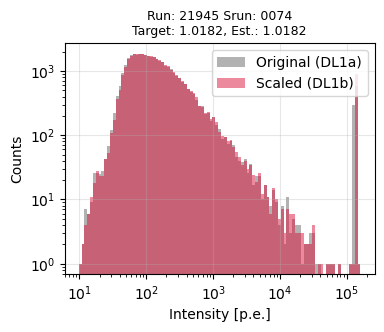

Sampling... Run 21923 srun 68... (10/10)

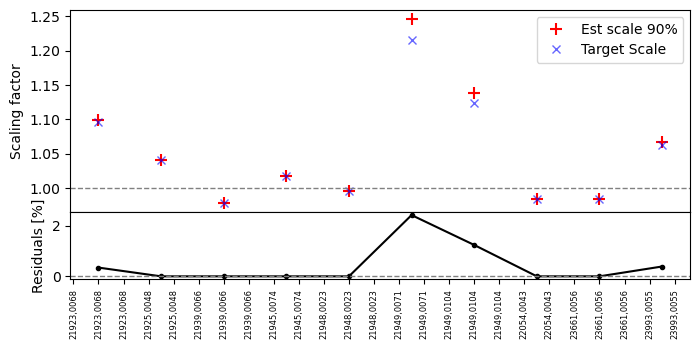

In [12]:
n_samples_runs = 10
n_samples_dist = 1
tail_perc = 90

hdf5_key = "/dl1/event/telescope/parameters/LST_LSTCam"

all_pairs = []
for obs_id, info in dict_results.items():
    all_files_srun_dl1 = glob.glob(os.path.join(root_dl1, f"dl1_LST-1.Run{obs_id:05}.????.h5"))
    file_srun_map_dl1 = {int(os.path.basename(f).split(".")[2]): f for f in all_files_srun_dl1}
    
    for sruns_batch in info["job_srun_batches"]:
        for srun in sruns_batch:
            if srun in file_srun_map_dl1:
                potential_output = os.path.join(path_dl1_s, f"dl1_LST-1.Run{obs_id:05}.{srun:04}.h5")
                if os.path.exists(potential_output):
                    all_pairs.append((obs_id, srun, file_srun_map_dl1[srun], potential_output))

sampled_pairs = random.sample(all_pairs, min(n_samples_runs, len(all_pairs)))
print(f"Sampling {len(sampled_pairs)} (run, subrun) pairs from {len(all_pairs)} available...")

obs_labels, expected_scales, est_shifts = [], [], []
for idx, (obs_id, chosen_srun, file_input, file_output) in enumerate(sampled_pairs):
    print(f"Sampling... Run {obs_id} srun {chosen_srun}... ({idx+1}/{len(sampled_pairs)})", end="\r")
    expected_scale = dict_results[obs_id]["scaling"]

    try:
        df_dl1a = pd.read_hdf(file_input, key=hdf5_key, columns=["event_id", "intensity"]).set_index("event_id")
        df_dl1b = pd.read_hdf(file_output, key=hdf5_key, columns=["event_id", "intensity"]).set_index("event_id")
    except Exception as e:
        print(f"\nError reading Run {obs_id} Srun {chosen_srun:04}: {e}")
        continue

    common_events = df_dl1a.index.intersection(df_dl1b.index)
    if len(common_events) == 0:
        print(f"\nSkipping Run {obs_id} Srun {chosen_srun:04}: No overlapping event IDs.")
        continue

    ia_all = df_dl1a.loc[common_events, "intensity"].values
    ib_all = df_dl1b.loc[common_events, "intensity"].values
    valid_mask = (ia_all > 0) & (ib_all > 0)
    ia, ib = ia_all[valid_mask], ib_all[valid_mask]

    if len(ia) == 0:
        print(f"Skipping Run {obs_id} Srun {chosen_srun:04}: No valid intensities.")
        continue

    tail_threshold = np.percentile(ia, tail_perc)
    tail_mask = ia > tail_threshold
    est_shift = np.median(ib[tail_mask] / ia[tail_mask])

    obs_labels.append(f"{obs_id},{chosen_srun:04}")
    expected_scales.append(expected_scale[chosen_srun])
    est_shifts.append(est_shift)

    if len(obs_labels) <= n_samples_dist:
        fig, ax = plt.subplots(figsize=(4, 3))
        bins = np.logspace(np.log10(ia.min()), np.log10(ia.max()), 100)
        ax.hist(ia, bins=bins, alpha=0.6, color="gray", label="Original (DL1a)")
        ax.hist(ib, bins=bins, alpha=0.5, color="crimson", label="Scaled (DL1b)")
        ax.set(xscale="log", yscale="log", xlabel="Intensity [p.e.]", ylabel="Counts")
        plt.title(f"Run: {obs_id} Srun: {chosen_srun:04}\nTarget: {expected_scale[chosen_srun]:.4f}, Est.: {est_shift:.4f}", fontsize=9)
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.show()

obs_labels, expected_scales, est_shifts = map(list, zip(*sorted(zip(obs_labels, expected_scales, est_shifts))))
residuals = np.abs(np.array(est_shifts) - np.array(expected_scales)) / np.array(est_shifts) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 3.5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(obs_labels, est_shifts, "+r", ms=8, markeredgewidth=1.5, label=f"Est scale {tail_perc}%")
ax1.plot(obs_labels, expected_scales, "x", color="blue", alpha=0.6, label="Target Scale")
ax2.plot(obs_labels, residuals, ".-", color="k", label="Residual")
ax1.axhline(1, color="0.5", ls="--", lw=1); ax2.axhline(0, color="0.5", ls="--", lw=1)
ax1.set(ylabel="Scaling factor"); ax2.set(ylabel="Residuals [%]")
ax1.legend(loc="upper right"); ax2.xaxis.set_major_locator(ticker.MaxNLocator(nbins=30))
ax2.tick_params(axis="x", labelrotation=90, labelsize=6)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

## Merging DL1 files

In [14]:
OVERWRITE = True

In [15]:
%%time
for obs_id in np.flip(obs_ids):
    if obs_id not in dict_results:
        continue

    file_dl1 = os.path.join(
        root_data, "real", "mono", source_name, version_lstchain, "Gamma", "prod_standard",
        "DL1scaled", f"dl1_LST-1.Run{obs_id:05}.h5"
    )

    if os.path.exists(file_dl1):
        if OVERWRITE:
            print(f"File {file_dl1} already exists. OVERWRITE is True, deleting file...")
            os.remove(file_dl1)
        else:
            print(f"  Skipping run {obs_id:04}: Output already exists.")
            continue
            
    print(f"Merging run {obs_id} ...")
    merge_command  = "lstchain_merge_hdf5_files "
    merge_command += f"--input-dir {os.path.dirname(file_dl1)} "
    merge_command += f"--output-file {file_dl1} "
    merge_command += f"--run-number {obs_id}"

    if PROCESS_INLINE:
        final_command = merge_command
    else:
        str_output = f"-o ./data/slurm_output/dl1_merge_{obs_id}.out"
        final_command = f"sbatch -p short --mem=12000 -J dl1_merge {str_output} --wrap='{merge_command}'"

    subprocess.run(final_command, shell=True, text=True)

File /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL1scaled/dl1_LST-1.Run23996.h5 already exists. OVERWRITE is True, deleting file...
Merging run 23996 ...
Submitted batch job 56429952
File /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL1scaled/dl1_LST-1.Run23995.h5 already exists. OVERWRITE is True, deleting file...
Merging run 23995 ...
Submitted batch job 56429953
File /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL1scaled/dl1_LST-1.Run23994.h5 already exists. OVERWRITE is True, deleting file...
Merging run 23994 ...
Submitted batch job 56429954
File /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL1scaled/dl1_LST-1.Run23993.h5 already exists. OVERWRITE is True, deleting file...
Merging run 23993 ...
Submitted batch job 56429955
File /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL1scaled/dl1_LST-1.Run23

In [16]:
!squeue -u juan.jimenez
# !scancel -u juan.jimenezeee

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON) 


## DL1 to DL2

In [20]:
OVERWRITE = False
PROCESS_INLINE = False

In [21]:
%%time
all_files_run_dl2 = glob.glob(os.path.join(
    root_data, "real", "mono", source_name, version_lstchain, "Gamma", "prod_standard",
    "DL1scaled", "dl1_LST-1.Run?????.h5"
))
file_run_map_dl2 = {int(os.path.basename(f).split("Run")[-1].split(".")[0]): f for f in all_files_run_dl2}

path_dl2_s = os.path.join(
    root_data, "real", "mono", source_name, version_lstchain, "Gamma", "prod_standard", "DL2scaled",
)
os.makedirs(path_dl2_s, exist_ok=True)

for i, obs_id in enumerate(obs_ids):
    if obs_id not in dict_results:
        continue

    file_dl1_s = file_run_map_dl2.get(obs_id)
    if file_dl1_s is None:
        print(f"Error: DL1 file for run {obs_id} not found in DL1scaled directory")
        continue

    dl1_filename = os.path.basename(file_dl1_s)
    dl2_filename = dl1_filename.replace("dl1_", "dl2_")
    expected_output_file = os.path.join(path_dl2_s, dl2_filename)

    if os.path.exists(expected_output_file):
        if OVERWRITE:
            print(f"- Overwrite is enabled. Removing existing file for Run {obs_id}...")
            os.remove(expected_output_file)
        else:
            print(f" - Run {obs_id} already has a DL2 file. Overwrite is off, skipping.")
            continue

    print(f"\nRunning DL1 --> DL2 for LST Run {obs_id} ({i+1}/{len(obs_ids)})...\n")

    str_nsb_tuning = dict_results[obs_id]["nsb_tuning"]
    dir_rf = os.path.join(root_rfs.replace("nsb_tuning_*", f"nsb_tuning_{str_nsb_tuning}"), str_dec)

    command_dl1dl2  = f"lstchain_dl1_to_dl2 "
    command_dl1dl2 += f"--input-files {file_dl1_s} "
    command_dl1dl2 += f"--path-models {dir_rf} "
    command_dl1dl2 += f"--output-dir {path_dl2_s} "
    command_dl1dl2 += f"--config {dict_results[obs_id]['config_file_dl2']}"

    str_output = f"-o ./data/slurm_output/dl1_to_dl2_light_scaling_{obs_id}.out"
    slurm_command = f"sbatch -p short --mem=80000 -J dl1_to_dl2 {str_output} --wrap='{command_dl1dl2}'"

    command = command_dl1dl2 if PROCESS_INLINE else slurm_command
    subprocess.run(command, shell=True, text=True)

 - Run 21404 already has a DL2 file. Overwrite is off, skipping.
 - Run 21405 already has a DL2 file. Overwrite is off, skipping.
 - Run 21726 already has a DL2 file. Overwrite is off, skipping.
 - Run 21727 already has a DL2 file. Overwrite is off, skipping.
 - Run 21816 already has a DL2 file. Overwrite is off, skipping.
 - Run 21817 already has a DL2 file. Overwrite is off, skipping.
 - Run 21921 already has a DL2 file. Overwrite is off, skipping.
 - Run 21922 already has a DL2 file. Overwrite is off, skipping.
 - Run 21923 already has a DL2 file. Overwrite is off, skipping.
 - Run 21924 already has a DL2 file. Overwrite is off, skipping.
 - Run 21925 already has a DL2 file. Overwrite is off, skipping.
 - Run 21926 already has a DL2 file. Overwrite is off, skipping.
 - Run 21927 already has a DL2 file. Overwrite is off, skipping.
 - Run 21928 already has a DL2 file. Overwrite is off, skipping.
 - Run 21929 already has a DL2 file. Overwrite is off, skipping.
 - Run 21930 already has 

In [22]:
!squeue -u juan.jimenez
# !scancel -u juan.jimenez

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON) 


--- Processing Run 23955 (1/6) ---
Applied scaling: 1.0205
Standard events: 3528223
Scaled events:   3586731
Ratio (S/Orig):  101.7%



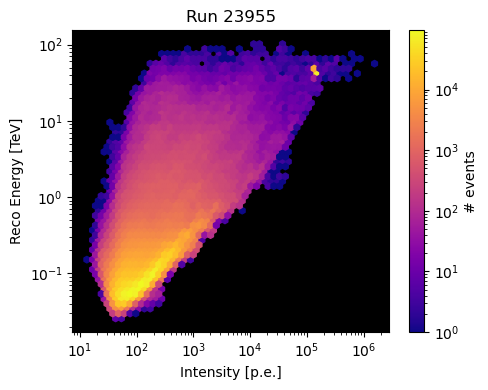

--- Processing Run 23493 (2/6) ---
Applied scaling: 0.9529
Standard events: 2020579
Scaled events:   2016633
Ratio (S/Orig):  99.8%



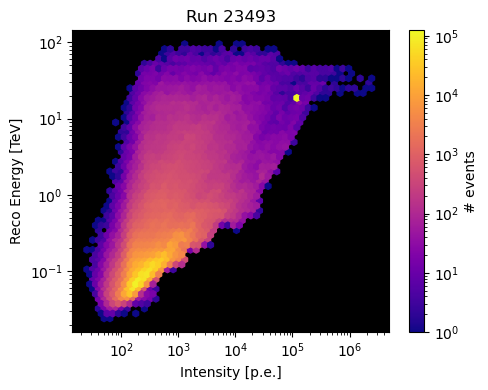

--- Processing Run 22742 (3/6) ---
Applied scaling: 0.9847
Standard events: 6280413
Scaled events:   6189090
Ratio (S/Orig):  98.5%



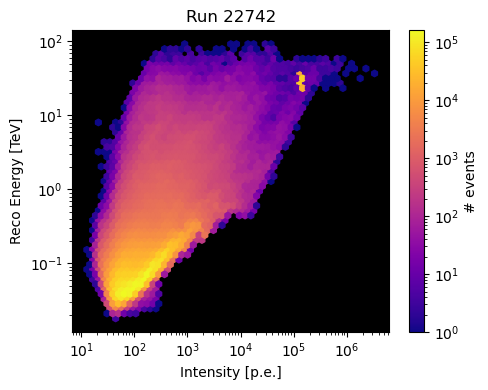

--- Processing Run 21404 (4/6) ---
Applied scaling: 1.2368
Standard events: 470515
Scaled events:   475361
Ratio (S/Orig):  101.0%



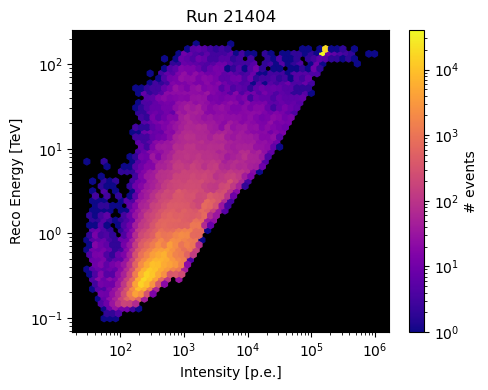

--- Processing Run 23559 (5/6) ---
Applied scaling: 0.9770
Standard events: 491028
Scaled events:   488552
Ratio (S/Orig):  99.5%



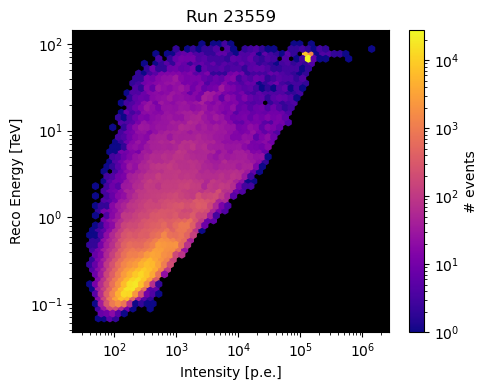

--- Processing Run 21921 (6/6) ---
Applied scaling: 0.9803
Standard events: 1577024
Scaled events:   1498097
Ratio (S/Orig):  95.0%



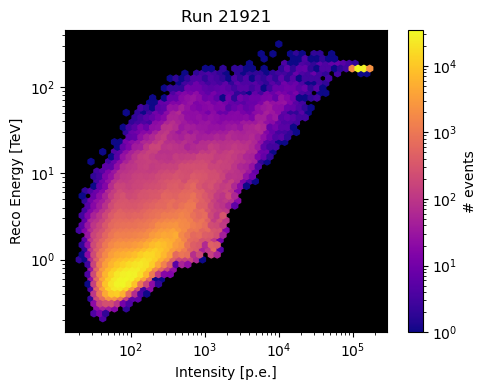

In [23]:
n_samples_plots = 6
dl2_key = "/dl2/event/telescope/parameters/LST_LSTCam"

available_runs = []
for obs_id in dict_results.keys():
    potential_file = os.path.join(
        path_dl2_s, f"dl2_LST-1.Run{obs_id:05}.h5"
    )
    if os.path.exists(potential_file):
        available_runs.append((obs_id, potential_file))

sampled_runs = random.sample(
    available_runs, min(n_samples_plots, len(available_runs))
)

for ii, (obs_id, file_dl2) in enumerate(sampled_runs):
    row_run = df_run.query(f"obs_id == {obs_id}")
    df_dl2 = pd.read_hdf(row_run["dl2_fname"].iloc[0], key=dl2_key)
    df_dl2_s = pd.read_hdf(file_dl2, key=dl2_key)
    _scale = row_run["ly_b3_scaling"].iloc[0]
    
    n_orig, n_scaled = len(df_dl2), len(df_dl2_s)
    ratio = n_scaled / n_orig if n_orig > 0 else 0
    color_scale = utils.R if _scale > 1 else utils.G
    color_ratio = utils.R if ratio > 1 else utils.G
    
    print(f"--- Processing Run {obs_id} ({ii+1}/{len(sampled_runs)}) ---")
    print(f"Applied scaling: {color_scale}{_scale:.4f}{utils.W}")
    print(f"Standard events: {n_orig}\nScaled events:   {n_scaled}")
    print(f"Ratio (S/Orig):  {color_ratio}{ratio*100:.1f}%{utils.W}\n")

    mask = (df_dl2_s["intensity"] > 0) & (df_dl2_s["reco_energy"] > 0)
    df_valid = df_dl2_s[mask]

    fig, ax = plt.subplots(figsize=(5, 4))

    hb = ax.hexbin(
        df_valid["intensity"], df_valid["reco_energy"], gridsize=50, 
        xscale="log", yscale="log", bins="log", cmap="plasma",
    )

    cb = plt.colorbar(hb, ax=ax, label="# events")
    ax.set(xlabel="Intensity [p.e.]", ylabel="Reco Energy [TeV]", title=f"Run {obs_id}", facecolor="k")
    plt.tight_layout()
    plt.show()

### Getting IRFs for every NSB

In [24]:
nsb_unique = np.unique(np.sort([dict_results[obs_id]["nsb_tuning"] for obs_id in obs_ids if obs_id in dict_results]))
print(f"Found {len(nsb_unique)} NSBs, preparing IRF dirs")

dict_nsbwise = {}
for nsb in nsb_unique:

    irf_files = glob.glob(os.path.join(
        root_irf.replace("nsb_tuning_*", f"nsb_tuning_{nsb}"),
        "Gamma", str_dec, "*", "irf_*.fits.gz"
    ))

    irf_path = os.path.join(
        root_data, "mc", "mono", "IRF", version_lstchain, f"NSB{nsb}",
        "Gamma", str_dec, "prod_standard", "gh_dyn70"
    ); os.makedirs(irf_path, exist_ok=True)

    dict_nsbwise[nsb] = {"irf_path": irf_path, "irf_files": irf_files}


Found 6 NSBs, preparing IRF dirs


##### Copying standard IRFs

In [25]:
%%time
if USE_STANDARD_IRFS:
    for nsb in dict_nsbwise.keys():
        irf_files = dict_nsbwise[nsb]["irf_files"]
        print(f"NSB {nsb}: Copying {len(irf_files)} files...")
        for filename in irf_files:
            shutil.copy(filename, dict_nsbwise[nsb]["irf_path"])

CPU times: user 2 μs, sys: 2 μs, total: 4 μs
Wall time: 10.5 μs


##### Computing the IRFs

In [26]:
OVERWRITE = False

In [27]:
%%time
NIRF_BATCH = 10

if not USE_STANDARD_IRFS:
    _any_obs_id = next(iter(dict_results))
    _config_dl3 = dict_results[_any_obs_id]["config_file_dl3"]

    for nsb in list(dict_nsbwise.keys()):
        query_mc_dl2 = glob.glob(os.path.join(
            root_mcs.replace("nsb_tuning_*", f"nsb_tuning_{nsb}"), "Gamma", str_dec, "*", "*.h5"
        ))
        print(f"\nComputing IRFs for NSB {nsb}... ({len(query_mc_dl2)} files)")

        pending = []
        for file_mc in query_mc_dl2:
            file_irf = os.path.join(
                dict_nsbwise[nsb]["irf_path"],
                file_mc.split("/")[-1].replace("dl2_", "irf_").replace(".h5", ".fits.gz")
            )
            if os.path.exists(file_irf) and not OVERWRITE:
                continue
            os.makedirs(os.path.dirname(file_irf), exist_ok=True)
            str_args  = f"--input-gamma-dl2 {file_mc} "
            str_args += f"--output-irf-file {file_irf} "
            str_args += f"--config {_config_dl3} "
            str_args += f"--overwrite " if OVERWRITE else ""
            str_args += f"--point-like "
            str_args += f"--energy-dependent-gh "
            str_args += f"--energy-dependent-theta"
            pending.append(f"lstchain_create_irf_files {str_args}")

        batches = [pending[i:i+NIRF_BATCH] for i in range(0, len(pending), NIRF_BATCH)]
        for k, batch in enumerate(batches):
            _command_ = " ; ".join(batch)
            str_output = f"-o ./data/slurm_output/irf_nsb{nsb}_batch{k}.out"
            slurm_command = f"sbatch -p short --mem=20000 -J irf_nsb{nsb} {str_output} --wrap='{_command_}'"
            final_command = _command_ if PROCESS_INLINE else slurm_command
            subprocess.run(final_command, shell=True, text=True)


Computing IRFs for NSB 0.22... (0 files)

Computing IRFs for NSB 0.38... (0 files)

Computing IRFs for NSB 0.50... (0 files)

Computing IRFs for NSB 0.81... (0 files)

Computing IRFs for NSB 1.25... (0 files)

Computing IRFs for NSB 1.76... (0 files)
CPU times: user 0 ns, sys: 1.92 ms, total: 1.92 ms
Wall time: 1.51 ms


In [28]:
!squeue -u juan.jimenez

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON) 


## DL2 to DL3 (scaled)

In [29]:
OVERWRITE = True
PROCESS_INLINE = True

In [30]:
%%time
NDL3_BATCH = 5

all_files_dl2_s = glob.glob(os.path.join(
    root_data, "real", "mono", source_name, version_lstchain, "Gamma", "prod_standard",
    "DL2scaled", "dl2_LST-1.Run?????.h5"
))
file_map_dl2_s = {int(os.path.basename(f).split("Run")[-1].split(".")[0]): f for f in all_files_dl2_s}

path_dl3_s = os.path.join(
    root_data, "real", "mono", source_name, version_lstchain, "Gamma", "prod_standard", "DL3scaled",
)
os.makedirs(path_dl3_s, exist_ok=True)

pending = []
for obs_id in obs_ids:
    if obs_id not in dict_results:
        continue
    expected_output_path = os.path.join(path_dl3_s, f"dl3_LST-1.Run{obs_id:05d}.fits")
    if os.path.exists(expected_output_path) and not OVERWRITE:
        print(f"Skipping Run {obs_id}: output exists and OVERWRITE is False.")
        continue
    file_dl2_s = file_map_dl2_s.get(obs_id)
    if file_dl2_s is None:
        print(f"Error: DL2 file for run {obs_id} not found in DL2scaled directory")
        continue
    irf_path = dict_nsbwise[dict_results[obs_id]["nsb_tuning"]]["irf_path"]
    str_args  = f" --input-dl2 {file_dl2_s} "
    str_args += f"--input-irf-path {irf_path} "
    str_args += f"--output-dl3-path {path_dl3_s} "
    str_args += f"--config {dict_results[obs_id]['config_file_dl3']} "
    str_args += f"--source-name {source_name} "
    str_args += f"--overwrite " if OVERWRITE else ""
    str_args += f"--source-ra {source_coords.ra.deg}deg "
    str_args += f"--source-dec {source_coords.dec.deg}deg"
    pending.append((obs_id, f"lstchain_create_dl3_file {str_args}"))

batches = [pending[i:i+NDL3_BATCH] for i in range(0, len(pending), NDL3_BATCH)]
for batch in batches:
    ids = [str(b[0]) for b in batch]
    print(f"Submitting: {', '.join(ids)}")
    _command_ = " ; ".join(cmd for _, cmd in batch)
    str_output = f"-o ./data/slurm_output/dl2_to_dl3_scaled_{'_'.join([ids[0], ids[-1]])}.out"
    slurm_command = f"sbatch -p short --mem=20000 -J dl2dl3_scaled {str_output} --wrap='{_command_}'"
    command = _command_ if PROCESS_INLINE else slurm_command
    subprocess.run(command, shell=True, text=True)

Submitting: 21404, 21405, 21726, 21727, 21816


2026-09-11 14:42:09,123 WARNING [lstchain.DataReductionFITSWriter] (lstchain_create_dl3_file.setup): Overwriting /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL3scaled/dl3_LST-1.Run21404.fits
/fefs/aswg/workspace/juan.jimenez/softs/conda/envs/env-lst-12/lib/python3.11/site-packages/tables/group.py:1220: UserWarning: problems loading leaf ``/provenance/dl1_to_dl2``::

  variable length strings are not supported yet

The leaf will become an ``UnImplemented`` node.
  warnings.warn(


The metadata are comparable
The other parameter axes data are comparable


2026-09-11 14:42:40,900 WARNING [lstchain.DataReductionFITSWriter] (lstchain_create_dl3_file.setup): Overwriting /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL3scaled/dl3_LST-1.Run21405.fits
/fefs/aswg/workspace/juan.jimenez/softs/conda/envs/env-lst-12/lib/python3.11/site-packages/tables/group.py:1220: UserWarning: problems loading leaf ``/provenance/dl1_to_dl2``::

  variable length strings are not supported yet

The leaf will become an ``UnImplemented`` node.
  warnings.warn(


The metadata are comparable
The other parameter axes data are comparable


...

The metadata are comparable
The other parameter axes data are comparable
Submitting: 23995, 23996


2026-09-11 16:17:15,441 WARNING [lstchain.DataReductionFITSWriter] (lstchain_create_dl3_file.setup): Overwriting /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL3scaled/dl3_LST-1.Run23995.fits
/fefs/aswg/workspace/juan.jimenez/softs/conda/envs/env-lst-12/lib/python3.11/site-packages/tables/group.py:1220: UserWarning: problems loading leaf ``/provenance/dl1_to_dl2``::

  variable length strings are not supported yet

The leaf will become an ``UnImplemented`` node.
  warnings.warn(


The metadata are comparable
The other parameter axes data are comparable


2026-09-11 16:18:14,006 WARNING [lstchain.DataReductionFITSWriter] (lstchain_create_dl3_file.setup): Overwriting /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL3scaled/dl3_LST-1.Run23996.fits
/fefs/aswg/workspace/juan.jimenez/softs/conda/envs/env-lst-12/lib/python3.11/site-packages/tables/group.py:1220: UserWarning: problems loading leaf ``/provenance/dl1_to_dl2``::

  variable length strings are not supported yet

The leaf will become an ``UnImplemented`` node.
  warnings.warn(


The metadata are comparable
The other parameter axes data are comparable
CPU times: user 1.09 s, sys: 9.33 s, total: 10.4 s
Wall time: 1h 38min 54s


## DL2 to DL3 (standard)

In [31]:
OVERWRITE = True

In [32]:
%%time
NDL3_BATCH = 5

path_dl3 = os.path.join(
    root_data, "real", "mono", source_name, version_lstchain, "Gamma", "prod_standard", "DL3",
)
os.makedirs(path_dl3, exist_ok=True)

pending = []
for obs_id in obs_ids:
    if obs_id not in dict_results:
        continue
    expected_output_path = os.path.join(path_dl3, f"dl3_LST-1.Run{obs_id:05d}.fits")
    if os.path.exists(expected_output_path) and not OVERWRITE:
        print(f"Skipping Run {obs_id}: output exists and OVERWRITE is False.")
        continue
    file_dl2 = dict_results[obs_id]["file_dl2_standard"]
    irf_path = dict_nsbwise[dict_results[obs_id]["nsb_tuning"]]["irf_path"]
    str_args  = f" --input-dl2 {file_dl2} "
    str_args += f"--input-irf-path {irf_path} "
    str_args += f"--output-dl3-path {path_dl3} "
    str_args += f"--config {dict_results[obs_id]['config_file_dl3']} "
    str_args += f"--overwrite " if OVERWRITE else ""
    str_args += f"--source-name {source_name} "
    str_args += f"--source-ra {source_coords.ra.deg}deg "
    str_args += f"--source-dec {source_coords.dec.deg}deg"
    pending.append((obs_id, f"lstchain_create_dl3_file {str_args}"))

batches = [pending[i:i+NDL3_BATCH] for i in range(0, len(pending), NDL3_BATCH)]
for batch in batches:
    ids = [str(b[0]) for b in batch]
    _command_ = " ; ".join(cmd for _, cmd in batch)
    str_output = f"-o ./data/slurm_output/dl2_to_dl3_{'_'.join([ids[0], ids[-1]])}.out"
    slurm_command = f"sbatch -p short --mem=20000 -J dl2dl3 {str_output} --wrap='{_command_}'"
    command = _command_ if PROCESS_INLINE else slurm_command
    subprocess.run(command, shell=True, text=True)

2026-09-11 16:18:53,935 WARNING [lstchain.DataReductionFITSWriter] (lstchain_create_dl3_file.setup): Overwriting /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL3/dl3_LST-1.Run21404.fits
/fefs/aswg/workspace/juan.jimenez/softs/conda/envs/env-lst-12/lib/python3.11/site-packages/tables/group.py:1220: UserWarning: problems loading leaf ``/provenance/dl1_to_dl2``::

  variable length strings are not supported yet

The leaf will become an ``UnImplemented`` node.
  warnings.warn(


The metadata are comparable
The other parameter axes data are comparable


2026-09-11 16:19:15,928 WARNING [lstchain.DataReductionFITSWriter] (lstchain_create_dl3_file.setup): Overwriting /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL3/dl3_LST-1.Run21405.fits
/fefs/aswg/workspace/juan.jimenez/softs/conda/envs/env-lst-12/lib/python3.11/site-packages/tables/group.py:1220: UserWarning: problems loading leaf ``/provenance/dl1_to_dl2``::

  variable length strings are not supported yet

The leaf will become an ``UnImplemented`` node.
  warnings.warn(


The metadata are comparable
The other parameter axes data are comparable


2026-09-11 16:19:39,390 WARNING [lstchain.DataReductionFITSWriter] (lstchain_create_dl3_file.setup): Overwriting /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL3/dl3_LST-1.Run21726.fits
/fefs/aswg/workspace/juan.jimenez/softs/conda/envs/env-lst-12/lib/python3.11/site-packages/tables/group.py:1220: UserWarning: problems loading leaf ``/provenance/dl1_to_dl2``::

  variable length strings are not supported yet

The leaf will become an ``UnImplemented`` node.
  warnings.warn(


...

The metadata are comparable
The other parameter axes data are comparable


2026-09-11 17:51:31,890 WARNING [lstchain.DataReductionFITSWriter] (lstchain_create_dl3_file.setup): Overwriting /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL3/dl3_LST-1.Run23995.fits
/fefs/aswg/workspace/juan.jimenez/softs/conda/envs/env-lst-12/lib/python3.11/site-packages/tables/group.py:1220: UserWarning: problems loading leaf ``/provenance/dl1_to_dl2``::

  variable length strings are not supported yet

The leaf will become an ``UnImplemented`` node.
  warnings.warn(


The metadata are comparable
The other parameter axes data are comparable


2026-09-11 17:52:38,354 WARNING [lstchain.DataReductionFITSWriter] (lstchain_create_dl3_file.setup): Overwriting /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL3/dl3_LST-1.Run23996.fits
/fefs/aswg/workspace/juan.jimenez/softs/conda/envs/env-lst-12/lib/python3.11/site-packages/tables/group.py:1220: UserWarning: problems loading leaf ``/provenance/dl1_to_dl2``::

  variable length strings are not supported yet

The leaf will become an ``UnImplemented`` node.
  warnings.warn(


The metadata are comparable
The other parameter axes data are comparable
CPU times: user 1.09 s, sys: 9.63 s, total: 10.7 s
Wall time: 1h 34min 22s


#### Creating index files

In [33]:
for str_args in [
    f"--input-dl3-dir={path_dl3} --file-pattern=dl3*fits --overwrite",
    f"--input-dl3-dir={path_dl3_s} --file-pattern=dl3*fits --overwrite",
]:
    slurm_command = f"lstchain_create_dl3_index_files {str_args}"
    subprocess.run(slurm_command, shell=True, text=True)

2026-09-11 17:53:19,197 WARNING [lstchain.FITSIndexWriter] (lstchain_create_dl3_index_files.setup): Overwriting /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL3/hdu-index.fits.gz
2026-09-11 17:53:19,221 WARNING [lstchain.FITSIndexWriter] (lstchain_create_dl3_index_files.setup): Overwriting /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL3/obs-index.fits.gz
2026-09-11 17:53:35,936 WARNING [lstchain.FITSIndexWriter] (lstchain_create_dl3_index_files.setup): Overwriting /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL3scaled/hdu-index.fits.gz
2026-09-11 17:53:35,938 WARNING [lstchain.FITSIndexWriter] (lstchain_create_dl3_index_files.setup): Overwriting /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL3scaled/obs-index.fits.gz


#### DL3 Verification: Standard vs Scaled

In [34]:
files_dl3   = sorted(glob.glob(os.path.join(path_dl3,   "dl3_LST-1.Run?????.fits")))
files_dl3_s = sorted(glob.glob(os.path.join(path_dl3_s, "dl3_LST-1.Run?????.fits")))

runs_std    = set(int(os.path.basename(f).split("Run")[1].split(".")[0]) for f in files_dl3)
runs_scaled = set(int(os.path.basename(f).split("Run")[1].split(".")[0]) for f in files_dl3_s)

print(f"Standard DL3 :  {len(runs_std)} files")
print(f"Scaled   DL3 :  {len(runs_scaled)} files")
print(f"Only in standard : {sorted(runs_std - runs_scaled)}")
print(f"Only in scaled   : {sorted(runs_scaled - runs_std)}")
print(f"Common runs      : {len(runs_std & runs_scaled)}")

Standard DL3 :  121 files
Scaled   DL3 :  112 files
Only in standard : [21818, 22058, 22059, 22600, 22983, 22986, 23010, 23092, 23895]
Only in scaled   : []
Common runs      : 112


In [35]:
def check_dl3_structure(filepath, label=""):
    with fits.open(filepath) as hdul:
        print(f"\n{'─'*60}")
        print(f"{label}  {os.path.basename(filepath)}")
        hdul.info()
        evts = hdul["EVENTS"].data
        print(f"  N events : {len(evts)}")
        print(f"  Columns  : {evts.dtype.names}")
        gti  = hdul["GTI"].data
        livetime = (gti["STOP"] - gti["START"]).sum()
        print(f"  Livetime : {livetime:.1f} s")
        ea   = hdul["EFFECTIVE AREA"].data
        ed   = hdul["ENERGY DISPERSION"].data
        print(f"  EA shape : {ea['EFFAREA'][0].shape}   ED shape: {ed['MATRIX'][0].shape}")

common_run = sorted(runs_std & runs_scaled)[0]
check_dl3_structure(os.path.join(path_dl3,   f"dl3_LST-1.Run{common_run:05d}.fits"), "STANDARD")
check_dl3_structure(os.path.join(path_dl3_s, f"dl3_LST-1.Run{common_run:05d}.fits"), "SCALED  ")


────────────────────────────────────────────────────────────
STANDARD  dl3_LST-1.Run21404.fits
Filename: /fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL3/dl3_LST-1.Run21404.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  EVENTS        1 BinTableHDU     79   18340R x 11C   [K, D, D, D, D, D, K, D, D, D, D]   
  2  GTI           1 BinTableHDU     29   1R x 2C   [D, D]   
  3  POINTING      1 BinTableHDU     44   1R x 5C   [D, D, D, D, D]   
  4  EFFECTIVE AREA    1 BinTableHDU     47   1R x 5C   [25D, 25D, D, D, 25D]   
  5  ENERGY DISPERSION    1 BinTableHDU     53   1R x 7C   [25D, 25D, 30D, 30D, D, D, 750D]   
  6  GH_CUTS       1 BinTableHDU     36   25R x 5C   [D, D, D, K, D]   
  7  RAD_MAX       1 BinTableHDU     51   1R x 5C   [25D, 25D, D, D, 25D]   
  N events : 18340
  Columns  : ('EVENT_ID', 'TIME', 'RA', 'DEC', 'ENERGY', 'GAMMANESS', 'MULTIP', 'GLON', 'GLAT', 'ALT

In [36]:
rows = []
for i, obs_id in enumerate(sorted(runs_std & runs_scaled)):
    print(f"Loading run {obs_id} ({i+1}/{len(obs_ids)})", end="\r")
    for tag, root in [("standard", path_dl3), ("scaled", path_dl3_s)]:
        f = os.path.join(root, f"dl3_LST-1.Run{obs_id:05d}.fits")
        with fits.open(f) as hdul:
            evts = hdul["EVENTS"].data
            gti  = hdul["GTI"].data
            lt   = (gti["STOP"] - gti["START"]).sum()
            rows.append({
                "obs_id"   : obs_id,
                "analysis" : tag,
                "n_events" : len(evts),
                "livetime" : round(lt, 1),
                "rate_Hz"  : round(len(evts) / lt, 4) if lt > 0 else np.nan,
                "E_mean_TeV": round(float(np.mean(evts["ENERGY"])), 4),
                "E_median_TeV": round(float(np.median(evts["ENERGY"])), 4),
                "gammaness_mean": round(float(np.mean(evts["GAMMANESS"])), 4),
            })

df_cmp = pd.DataFrame(rows)
df_pivot = df_cmp.pivot(index="obs_id", columns="analysis",
                        values=["n_events", "rate_Hz", "E_mean_TeV", "gammaness_mean"])
df_pivot.columns = ["_".join(c) for c in df_pivot.columns]
df_pivot["delta_n_events_%"] = (
    (df_pivot["n_events_scaled"] - df_pivot["n_events_standard"])
    / df_pivot["n_events_standard"] * 100
).round(2)
df_pivot["delta_rate_%"] = (
    (df_pivot["rate_Hz_scaled"] - df_pivot["rate_Hz_standard"])
    / df_pivot["rate_Hz_standard"] * 100
).round(2)
df_pivot["delta_E_mean_%"] = (
    (df_pivot["E_mean_TeV_scaled"] - df_pivot["E_mean_TeV_standard"])
    / df_pivot["E_mean_TeV_standard"] * 100
).round(2)

print(df_pivot.to_string())

        n_events_scaled  n_events_standard  rate_Hz_scaled  rate_Hz_standard  E_mean_TeV_scaled  E_mean_TeV_standard  gammaness_mean_scaled  gammaness_mean_standard  delta_n_events_%  delta_rate_%  delta_E_mean_%
obs_id                                                                                                                                                                                                              
21404           28355.0            18340.0         48.4780           31.3545             0.3981               0.4119                 0.4698                   0.4295             54.61         54.61           -3.35
21405           19175.0            18113.0         33.6445           31.7806             0.3365               0.3397                 0.5118                   0.4566              5.86          5.86           -0.94
21726          565162.0           560756.0        504.5793          500.6458             0.1459               0.1448                 0.3218         

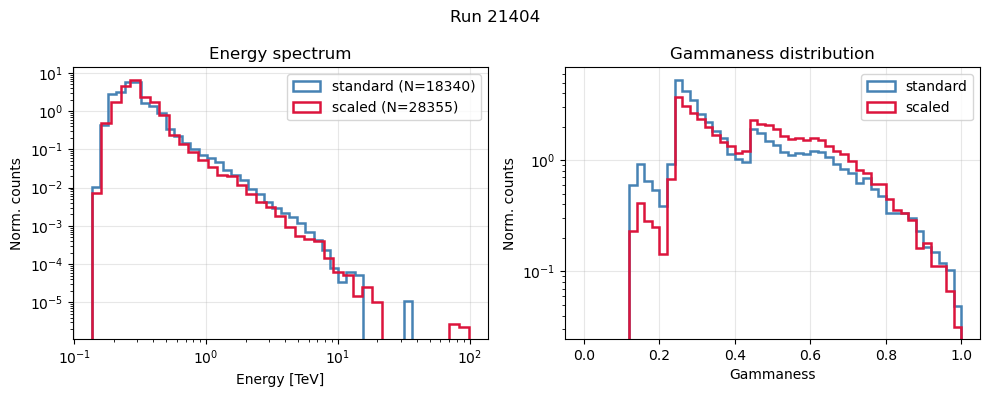

In [37]:
obs_id = sorted(runs_std & runs_scaled)[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(f"Run {obs_id}")

for tag, root, color in [("standard", path_dl3, "steelblue"), ("scaled", path_dl3_s, "crimson")]:
    with fits.open(os.path.join(root, f"dl3_LST-1.Run{obs_id:05d}.fits")) as hdul:
        evts = hdul["EVENTS"].data
        energy    = evts["ENERGY"]
        gammaness = evts["GAMMANESS"]

    bins_e = np.logspace(np.log10(energy.min()), np.log10(energy.max()), 40)
    axes[0].hist(energy, bins=bins_e, histtype="step", lw=1.8,
                 label=f"{tag} (N={len(energy)})", color=color, density=True)
    axes[1].hist(gammaness, bins=50, range=(0, 1), histtype="step", lw=1.8,
                 label=tag, color=color, density=True)

axes[0].set(xscale="log", yscale="log", xlabel="Energy [TeV]", ylabel="Norm. counts", title="Energy spectrum")
axes[1].set(xlabel="Gammaness", yscale="log", ylabel="Norm. counts", title="Gammaness distribution")
for ax in axes:
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
print(obs_ids)

[21404, 21405, 21726, 21727, 21816, 21817, 21921, 21922, 21923, 21924, 21925, 21926, 21927, 21928, 21929, 21930, 21931, 21939, 21940, 21941, 21942, 21943, 21944, 21945, 21946, 21947, 21948, 21949, 21950, 21951, 22028, 22029, 22030, 22049, 22050, 22051, 22052, 22053, 22054, 22055, 22056, 22057, 22060, 22326, 22327, 22569, 22598, 22599, 22740, 22741, 22742, 22743, 22825, 22826, 22827, 22987, 22988, 22989, 22990, 23009, 23011, 23012, 23039, 23040, 23049, 23087, 23088, 23089, 23090, 23091, 23093, 23094, 23095, 23281, 23282, 23283, 23284, 23432, 23491, 23492, 23493, 23559, 23560, 23561, 23562, 23656, 23657, 23658, 23659, 23660, 23661, 23662, 23664, 23665, 23666, 23667, 23668, 23669, 23670, 23671, 23896, 23897, 23898, 23955, 23956, 23957, 23958, 23992, 23993, 23994, 23995, 23996]
